<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjhamilton/weeks/week_08/08_Diffusion_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 08: Building the AI/ML pipeline

Last week you built every diffusion-specific piece of mathematics the model
needs — in pure numpy, with every line transparent and debuggable. The
**forward process** that maps a clean residual to noise across T = 200 timesteps,
the **cosine noise schedule** that defines α_t and σ_t at every t, and the
empirical verifications that the corruption behaves the way the math says it
should. The window table, the stratified split, and the schedule are all
saved to `diffusion_windows.parquet`. What you have *not* built is anything
with learnable parameters.

That changes this week. The forward apparatus from Week 07 will be reused
unchanged; on top of it we add the **reverse process** — a small denoising
neural network whose job is to estimate ε from r_t, trained in PyTorch with
PyTorch Lightning. By the end of this notebook you will have an end-to-end
**unconditional diffusion model** that learns the marginal distribution of
residuals, samples from it, and — through a deliberate architectural
ablation — answers a real empirical question: does the network's awareness
of the noise level (the **timestep embedding**) actually earn its keep on
this dataset?

**Strategic context.** This week is the most code-heavy of the three. The
conceptual lift is smaller than Week 07's diffusion math — the hard ideas
(forward process, schedule, ε-prediction) are already in your toolkit. What
this week demands is *integration*: turning the numpy schedule into a
PyTorch buffer, turning the residual table into a Dataset, turning the
training equation into a Lightning training step, and watching the whole
thing learn. Most of you will encounter the canonical AI/ML pipeline
(Dataset → DataLoader → Model → LightningModule → Trainer) for the first
time here. The pipeline is not diffusion-specific — every PyTorch project
you ever build will have the same five pieces — but each piece has a
diffusion-specific wrinkle, and we will flag those wrinkles as we go.

**One deliberate omission this week: conditioning.** The Week 09 model will
condition on (cycle amplitude, universal-path latitude) and run through
`compute_global_nll`. This week we train the *unconditional* version: it
learns the marginal distribution of residuals across all training cycles
and can sample plausible residuals, but it cannot target a specific window.
The reason for the split is pedagogical: build the diffusion machinery
first, feel it work end-to-end, and only then add the conditioning layer
on top. One new idea per week.

**By the end of this notebook you should be able to:**
- Wrap the Week 07 residual table (loaded from `diffusion_windows.parquet`)
  in a **PyTorch Dataset** and explain why the dataset for diffusion training
  returns clean residuals only — without any noise injection or timestep
  sampling.
- Build the three **DataLoaders** (train / val / test) using the `split`
  column already present in the parquet, and articulate why shuffling
  matters for training but not for validation.
- Implement a **sinusoidal timestep embedding** that maps the integer t to a
  dense vector, and visualize how the embedding rotates through embedding
  space as t varies.
- Build a **DiffusionMLP** that takes (r_t, t) and returns ε̂, with a
  constructor flag that toggles whether the timestep embedding is used at
  all — the architectural ablation that lets you measure whether t-awareness
  earns its keep.
- Write a **PyTorch Lightning training loop** that samples t per batch
  element, draws ε, applies the Week 07 forward equation in PyTorch, and
  trains on MSE loss against the true ε.
- Implement a **DDIM-style sampler** that runs the trained model in reverse
  to generate new residuals, and verify that the sampled residuals match
  the training distribution on bin-wise mean, standard deviation, and
  covariance structure.
- Run the with-vs-without-timestep-embedding ablation and read its result
  honestly, including the case where it tells you something uncomfortable
  about your architecture choice.


In [2]:
import os, subprocess, sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [4]:
pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.4 MB/s eta 0:00:00


In [5]:
import os, sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange, repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger

In [7]:
# ── locate repo root robustly (same scheme as Week 07) ──────────────────────
# Use the already defined repo_path from the setup cell
_repo_root = repo_path # This is /content/butterflai
_week8_dir = os.path.join(_repo_root, "weeks", "week_08")

if not os.path.isfile(os.path.join(_week8_dir, "butterflAI_model.py")):
    raise FileNotFoundError(
        "Cannot locate butterflAI_model.py. Make sure repo_path points to the "
        "butterflai repo root, and that you have run Week 07 to produce "
        "diffusion_windows.parquet."
    )

for _p in [_week8_dir, _repo_root]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── load Week 07 outputs ─────────────────────────────────────────────────────
windows_df = pd.read_parquet(Path(_week8_dir) / "diffusion_windows.parquet")

hist_cols = [f"hist_emp_{j:02d}" for j in range(15)]
par_cols  = [f"hist_par_{j:02d}" for j in range(15)]

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

# ── load the official ButterflAI classical model ─────────────────────────────
from butterflAI_model import ButterflAIModel
classical = ButterflAIModel(os.path.join(_week8_dir, "official_model.npz"))

print(f"Loaded {len(windows_df)} windows from diffusion_windows.parquet")
print(f"  splits : {windows_df['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles : {sorted(windows_df['cycle'].unique())}")
print(classical)

Loaded 373 windows from diffusion_windows.parquet
  splits : {'test': 86, 'train': 232, 'val': 55}
  cycles : [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
<ButterflAIModel  N_hemicycles=26  NLL=3.0708  coverage=0.963>


In [8]:
# ── recompute the Week 07 cosine schedule (numpy version) ──────────────────
# Same formula as Week 07 Task 28. Kept here so this notebook is
# self-contained — the LightningModule in Task 40 will build a torch
# version of the same schedule from these arrays.
T, s_offset = 200, 0.008
_t_arr         = np.arange(T + 1, dtype=float)
_f0            = np.cos(np.pi / 2 * s_offset / (1 + s_offset)) ** 2
_alpha_bar_raw = np.cos(np.pi / 2 * (_t_arr / T + s_offset) / (1 + s_offset)) ** 2 / _f0
_alpha_bar_raw = np.clip(_alpha_bar_raw, 0.0, 1.0)
_beta = np.zeros(T + 1)
for t in range(1, T + 1):
    _beta[t] = np.clip(1.0 - _alpha_bar_raw[t] / _alpha_bar_raw[t - 1], 1e-8, 0.999)
alpha_bar_np = np.ones(T + 1)
for t in range(1, T + 1):
    alpha_bar_np[t] = alpha_bar_np[t - 1] * (1.0 - _beta[t])
alpha_np = np.sqrt(alpha_bar_np)
sigma_np = np.sqrt(np.clip(1.0 - alpha_bar_np, 0.0, 1.0))

print(f"T={T}, schedule arrays length {len(alpha_np)}")

T=200, schedule arrays length 201


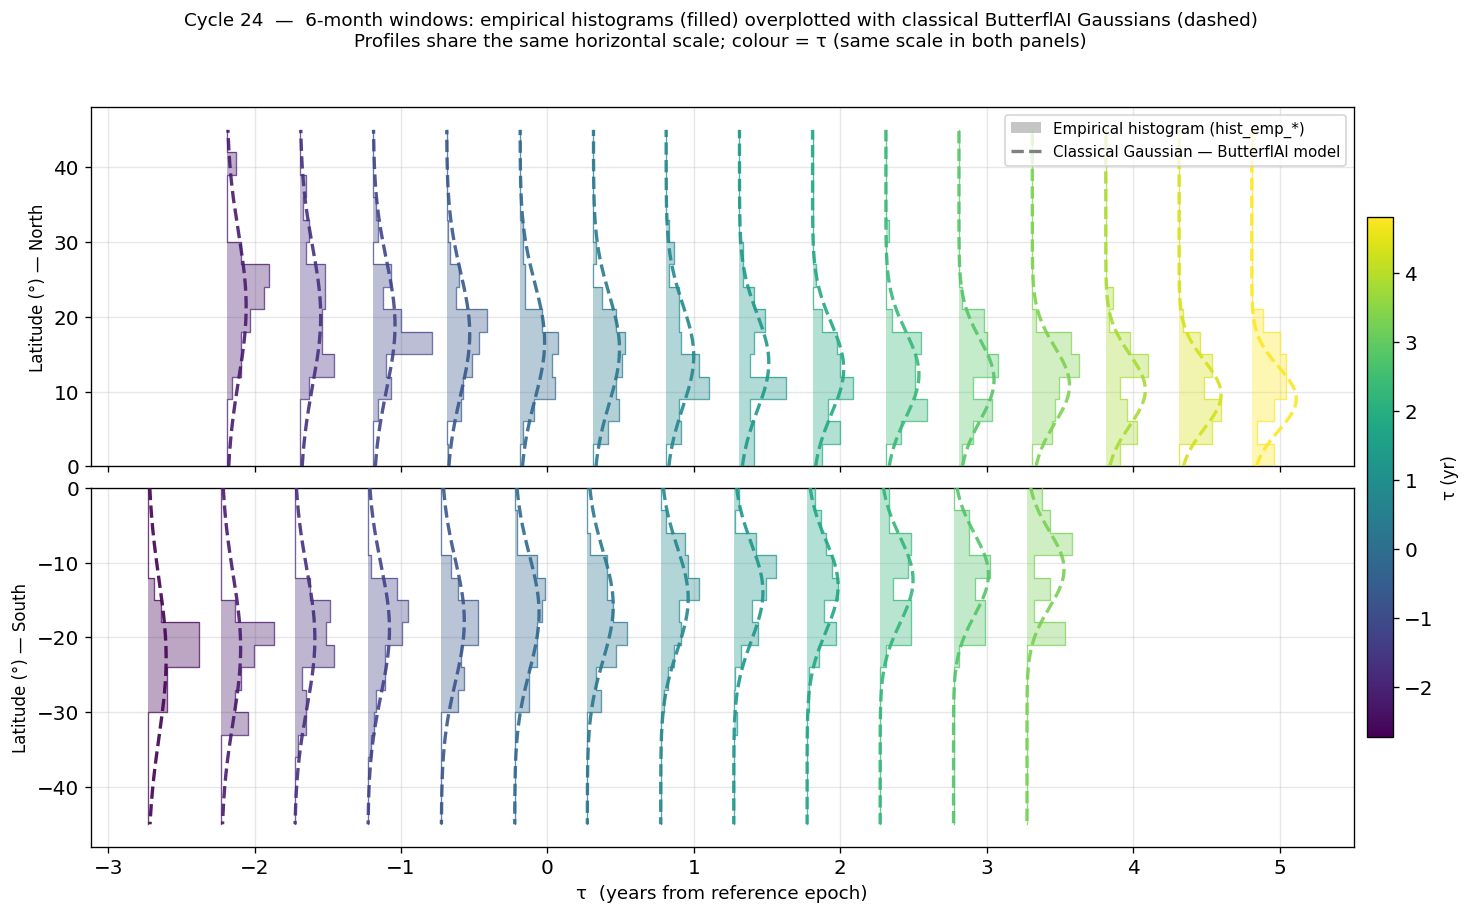

In [9]:
# ── Inspect the classical model on any cycle in windows_df ─────────────────
# Change cycle_number to see a different cycle.  Both hemispheres are shown
# simultaneously.  Filled profiles = empirical 6-month histogram (hist_emp_*);
# dashed curves = classical ButterflAI Gaussian evaluated at the same (A, τ).
cycle_number  = 24      # ← any value in sorted(windows_df['cycle'].unique())
PROFILE_SCALE = 0.40    # max density → this many τ-years of horizontal width

# ── select & sort windows ─────────────────────────────────────────────────
wdf_n = (windows_df[(windows_df["cycle"] == cycle_number) &
                     (windows_df["hemisphere"] == "north")]
         .sort_values("tau_center").reset_index(drop=True))
wdf_s = (windows_df[(windows_df["cycle"] == cycle_number) &
                     (windows_df["hemisphere"] == "south")]
         .sort_values("tau_center").reset_index(drop=True))

if wdf_n.empty and wdf_s.empty:
    raise ValueError(
        f"Cycle {cycle_number} not found. "
        f"Available: {sorted(windows_df['cycle'].unique())}"
    )

# Shared normalization across both hemispheres so relative amplitudes are comparable
_cyc_mask  = windows_df["cycle"] == cycle_number
global_max = max(windows_df[_cyc_mask][hist_cols].values.max(), 1e-9)
scale      = PROFILE_SCALE / global_max

# Shared τ range for colormap — same colour = same time in both panels
_all_tau   = pd.concat([wdf_n["tau_center"], wdf_s["tau_center"]])
tau_norm   = plt.Normalize(vmin=_all_tau.min(), vmax=_all_tau.max())
cmap_win   = plt.get_cmap("viridis")

# Step-function bin edges for fill_betweenx  (15 bins → 30 edge positions)
_lat_edges_step = np.concatenate(
    [[LAT_BINS[0]], np.repeat(LAT_BINS[1:-1], 2), [LAT_BINS[-1]]]
)   # shape (30,)
_lat_fine = np.linspace(0, 45, 300)   # fine grid for smooth Gaussian curves

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.subplots_adjust(hspace=0.06)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

for ax, wdf, sign, hemi_label in [
    (axes[0], wdf_n, +1, "North"),
    (axes[1], wdf_s, -1, "South"),
]:
    if wdf.empty:
        ax.text(0.5, 0.5, f"No data for {hemi_label}",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=13, color="gray")
        ax.set_ylabel("Latitude (°)")
        continue

    for _, row in wdf.iterrows():
        tau   = row["tau_center"]
        A     = row["amplitude"]
        color = cmap_win(tau_norm(tau))

        # ── empirical histogram: filled step-function profile ────────────
        hist_vals = row[hist_cols].values.astype(float)
        hist_step = np.repeat(hist_vals, 2)        # (30,)
        x_hist    = tau + hist_step * scale

        lats_plot = sign * _lat_edges_step
        ax.fill_betweenx(lats_plot, tau, x_hist,
                         color=color, alpha=0.35, linewidth=0, zorder=2)
        ax.plot(x_hist, lats_plot,
                color=color, linewidth=0.8, alpha=0.75, zorder=3)

        # ── classical Gaussian: smooth dashed curve ───────────────────────
        gauss_vals = classical.density(A, tau, _lat_fine)
        x_gauss    = tau + gauss_vals * scale
        ax.plot(x_gauss, sign * _lat_fine,
                color=color, linewidth=2.0, linestyle="--", alpha=0.9, zorder=5)

    ax.set_ylabel(f"Latitude (°) — {hemi_label}", fontsize=10)
    ax.set_ylim((0, 48) if sign == 1 else (-48, 0))

    if sign == 1:   # legend once, in the north panel
        ax.legend(
            handles=[
                Patch(facecolor="gray", alpha=0.45,
                      label="Empirical histogram (hist_emp_*)"),
                Line2D([0], [0], color="gray", linewidth=2, linestyle="--",
                       label="Classical Gaussian — ButterflAI model"),
            ],
            loc="upper right", fontsize=9,
        )

# ── single shared colorbar spanning both panels ───────────────────────────
sm = plt.cm.ScalarMappable(cmap="viridis", norm=tau_norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=axes, pad=0.01, fraction=0.02)
cb.set_label("τ (yr)", fontsize=10)

axes[1].set_xlabel("τ  (years from reference epoch)", fontsize=11)
fig.suptitle(
    f"Cycle {cycle_number}  —  6-month windows: "
    "empirical histograms (filled) overplotted with classical ButterflAI Gaussians (dashed)\n"
    "Profiles share the same horizontal scale; colour = τ (same scale in both panels)",
    fontsize=11,
)
plt.show()

---
# Week 08 Tasks: Building the AI/ML pipeline

Everything above this line is **setup**: the Week 07 outputs are loaded,
the cosine schedule is recomputed in numpy for reference, and the
official `ButterflAIModel` is instantiated. Below this line begins the
Week 08 work proper: build the dataset, the model, the training loop, the
sampler, and the ablation comparison.

The tasks build sequentially. Tasks 33–35 wrap the Week 07 residual table
in a PyTorch Dataset and DataLoader. Tasks 36–39 build the model in three
layered pieces (sinusoidal embedding → embedding module → main network)
and then sanity-test it. Task 40 stitches the model and the schedule into
a LightningModule. Task 41 trains it. Tasks 42–43 implement sampling and
verify the sampled distribution matches the training distribution. Task 44
runs the ablation experiment and produces the comparison table that closes
the week.

A note on convention: throughout this notebook, all tensor shape
manipulation uses `einops.rearrange` and `einops.repeat` with named
dimensions rather than `view`, `reshape`, `squeeze`, `unsqueeze`,
`expand`, or `tile`. The named-dimension form makes the shape semantics
explicit, which is especially useful when multiple dimensions could
plausibly be the batch dimension. `einops` was already required for
Week 07 and is available in the environment.


---
## Task 33 — Wrap the residual table in a PyTorch Dataset

The Week 07 residual table has one row per (cycle, hemisphere, 6-month
window) and a `split` column tagging each row as `'train'`, `'val'`, or
`'test'`. Most diffusion training pipelines call this object a **Dataset**:
an indexed collection of clean data points that the training loop will
draw from at random.

The dataset for
diffusion training is simple. In supervised learning  `__getitem__` typically returns an (input, target) pair. For diffusion, that is
not the right factoring. The triple (r_t, t, ε) the network actually trains
on is generated *inside* the Lightning training step, not in `__getitem__`.
The dataset returns just the clean residual r; the timestep t is sampled
fresh per batch, the noise ε is drawn fresh per batch, and the corruption
r_t = α_t · r + σ_t · ε is computed on the fly using the same formula
your Week 07 `forward_corrupt` implemented. This separation is deliberate:
it lets you change the timestep sampling distribution, the ε distribution,
or the loss weighting without ever touching the dataset.

This week the dataset returns *only*
the residual, as a tensor of shape (15,). Week 09 will add conditioning on
(amplitude, mu_universal), which means the dataset will need to return
those covariates alongside the residual. We do not preemptively wire that
in this week — keeping the dataset minimal makes the diffusion-specific
machinery easier to see — but the parquet already contains those columns,
so the Week 09 refactor will be small.

**Tasks:**
- Define a class `ResidualDataset(torch.utils.data.Dataset)` that wraps
  `windows_df`.
- The constructor takes the full `windows_df` and a string `split` in
  `{'train', 'val', 'test'}`, and filters the DataFrame to retain only
  rows whose `split` column matches.
- `__len__` returns the number of rows after filtering.
- `__getitem__(idx)` extracts the residual (the difference between the 15
  `hist_emp_*` columns and the 15 `hist_par_*` columns) and returns it as
  a single `torch.float32` tensor of shape `(15,)`.

**Important:** the residual is the *difference* between the empirical and
parametric histograms (both densities). It is not normalized to unit
variance, not centered at zero, and not bounded — it is in the same units
as the histograms (probability density per latitude). The diffusion model
will learn to generate residuals with whatever distributional structure
the training data exhibits, so do not preprocess them here. The
`hist_par_*` columns themselves were generated in Week 07 by integrating
the official classical model's per-window Gaussian over each bin; the
residual you return here is the part of the per-window density the
classical model leaves on the table.


In [10]:
class ResidualDataset(torch.utils.data.Dataset):
    def __init__(self, windows_df, split):
        # Filter the DataFrame based on the split
        self.data = windows_df[windows_df['split'] == split].copy()

        # Prepare column names for empirical and parametric histograms
        hist_emp_cols = [f"hist_emp_{j:02d}" for j in range(15)]
        hist_par_cols = [f"hist_par_{j:02d}" for j in range(15)]

        # Precompute residuals for efficiency
        self.residuals = torch.from_numpy(
            (self.data[hist_emp_cols].values - self.data[hist_par_cols].values)
        ).float()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Return the precomputed residual for the given index
        return self.residuals[idx]

---
## Task 34 — Test and visualize the dataset

A dataset class is one of the easier objects to silently misimplement
because most bugs do not raise — they just return wrongly-shaped or
wrongly-typed tensors that surface as cryptic errors three layers deeper
in the training loop. Spend a few cells here on visual and numerical
sanity checks before moving on.

**Tasks:**
- Instantiate three datasets: `train_dataset`, `val_dataset`, `test_dataset`,
  using the `split` column. Print `len(...)` for each. The counts should
  match the values printed by the setup cell.
- Pull one sample from `train_dataset` (e.g. `train_dataset[0]`) and verify:
  - Its type is `torch.Tensor`.
  - Its shape is `(15,)`.
  - Its dtype is `torch.float32`.
  - It contains no `NaN` or `Inf` values.
- Pick four random rows from the training set and overplot them as bar
  charts on a 2 × 2 grid using `BIN_CENTERS` for the x-axis. They should
  look like residuals: roughly zero-mean across bins (because empirical
  and parametric densities both integrate to ~1 on the same grid), small
  at the edge bins (0–3° and 42–45°, near-empty in the data), and
  structured in the middle bins where the Spörer zone lives.
- Compute and print the bin-wise mean and standard deviation across the
  full training set. The bin-wise mean should be small (a few percent of
  density at most); the bin-wise standard deviation should be larger,
  reflecting the cycle-to-cycle structure the diffusion model will need
  to learn.


In [11]:
# Instantiate datasets
train_dataset = ResidualDataset(windows_df, 'train')
val_dataset = ResidualDataset(windows_df, 'val')
test_dataset = ResidualDataset(windows_df, 'test')

print(f"Train dataset length: {len(train_dataset)}")
print(f"Validation dataset length: {len(val_dataset)}")
print(f"Test dataset length: {len(test_dataset)}")

Train dataset length: 232
Validation dataset length: 55
Test dataset length: 86


### Sample Inspection

In [12]:
# Pull one sample from train_dataset
sample_residual = train_dataset[0]

# Verify properties
print(f"Sample type: {type(sample_residual)}")
print(f"Sample shape: {sample_residual.shape}")
print(f"Sample dtype: {sample_residual.dtype}")
print(f"Contains NaN: {torch.isnan(sample_residual).any()}")
print(f"Contains Inf: {torch.isinf(sample_residual).any()}")

Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([15])
Sample dtype: torch.float32
Contains NaN: False
Contains Inf: False


### Visualize random samples

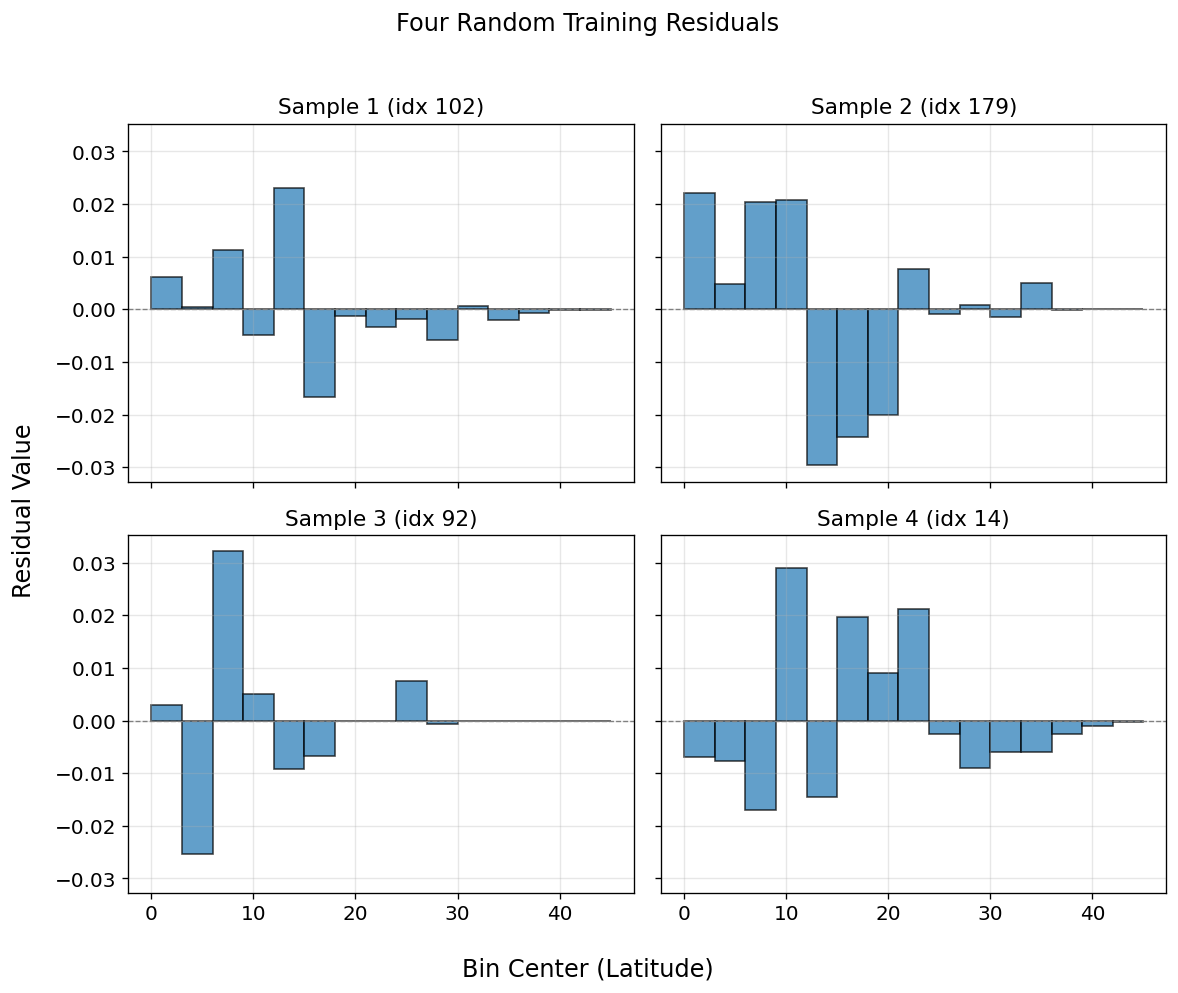

In [13]:
# Pick four random rows from the training set and overplot them as bar charts
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(4):
    # Get a random index
    idx = np.random.randint(0, len(train_dataset))
    residual = train_dataset[idx].numpy()
    axes[i].bar(BIN_CENTERS, residual, width=BIN_WIDTH, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Sample {i+1} (idx {idx})')
    axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)

fig.suptitle('Four Random Training Residuals', y=1.02)
fig.supxlabel('Bin Center (Latitude)')
fig.supylabel('Residual Value')
plt.tight_layout()
plt.show()

### Bin-wise mean and standard deviation across the full training set

Bin-wise Mean of Training Residuals:
tensor([-0.0032,  0.0001,  0.0004,  0.0002,  0.0036,  0.0062,  0.0041,  0.0030,
        -0.0009, -0.0013, -0.0020, -0.0020, -0.0012, -0.0008, -0.0005])

Bin-wise Standard Deviation of Training Residuals:
tensor([0.0090, 0.0184, 0.0231, 0.0234, 0.0230, 0.0220, 0.0204, 0.0211, 0.0112,
        0.0101, 0.0063, 0.0053, 0.0039, 0.0026, 0.0015])


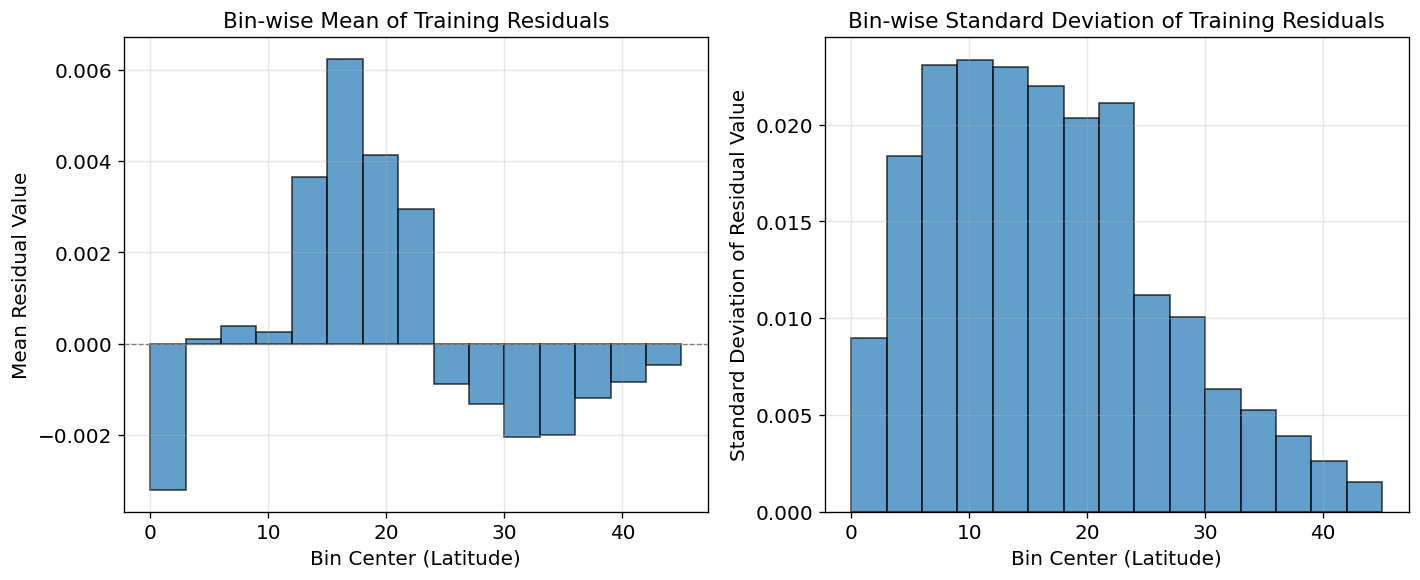

In [14]:
# Concatenate all training residuals to compute statistics
all_train_residuals = torch.stack([train_dataset[i] for i in range(len(train_dataset))])

# Compute bin-wise mean and standard deviation
bin_wise_mean = all_train_residuals.mean(dim=0)
bin_wise_std = all_train_residuals.std(dim=0)

print("Bin-wise Mean of Training Residuals:")
print(bin_wise_mean)
print("\nBin-wise Standard Deviation of Training Residuals:")
print(bin_wise_std)

# Visualize mean and std
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(BIN_CENTERS, bin_wise_mean.numpy(), width=BIN_WIDTH, edgecolor='black', alpha=0.7)
axes[0].set_title('Bin-wise Mean of Training Residuals')
axes[0].set_xlabel('Bin Center (Latitude)')
axes[0].set_ylabel('Mean Residual Value')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)

axes[1].bar(BIN_CENTERS, bin_wise_std.numpy(), width=BIN_WIDTH, edgecolor='black', alpha=0.7)
axes[1].set_title('Bin-wise Standard Deviation of Training Residuals')
axes[1].set_xlabel('Bin Center (Latitude)')
axes[1].set_ylabel('Standard Deviation of Residual Value')

plt.tight_layout()
plt.show()

---
## Task 35 — Build the DataLoaders

A `Dataset` is an indexed collection; a `DataLoader` is the object that
samples batches from it during training. The DataLoader's job is to handle
batching, shuffling, parallel data loading, and the iteration protocol the
Lightning trainer expects.

There is one design choice worth flagging that is not diffusion-specific
but is easy to get wrong: `shuffle=True` for the *training* loader and
`shuffle=False` for validation and test. The reason for shuffling at
training time is that stochastic gradient descent assumes batches are
roughly i.i.d. samples from the data distribution; if batches are returned
in a fixed order (especially if the data is sorted by cycle, as our
parquet roughly is), the gradient is biased per epoch and the model can
fit cycle-by-cycle artifacts. For validation and test, the order does not
affect the loss value; we leave shuffling off so that successive
validation runs produce identical batch orderings, which keeps val/test
metrics reproducible across epochs.

**Tasks:**
- Build three DataLoaders using `torch.utils.data.DataLoader`:
  - `train_loader`: `batch_size=64`, `shuffle=True`, `num_workers=0`
    (Colab is happiest with 0 here).
  - `val_loader`: `batch_size=64`, `shuffle=False`, `num_workers=0`.
  - `test_loader`: `batch_size=64`, `shuffle=False`, `num_workers=0`.
- Iterate one batch from each loader (`next(iter(loader))`) and verify:
  - The batch is a tensor of shape `(64, 15)` (or smaller for the last
    batch if the dataset size is not divisible by 64).
  - The dtype is `torch.float32`.
- Print the number of batches per epoch for each loader (`len(loader)`).

**Note for later:** with 15-dim data and batch size 64, a full pass through
the training set is fast — well under a second on Colab's GPU. We will
lean into this in Task 41 by training for many epochs.


In [15]:
# Build DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True, num_workers=0
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=64, shuffle=False, num_workers=0
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=0
)

# Verify batch properties for train_loader
sample_batch_train = next(iter(train_loader))
print(f"Train batch type: {type(sample_batch_train)}")
print(f"Train batch shape: {sample_batch_train.shape}")
print(f"Train batch dtype: {sample_batch_train.dtype}")

# Verify batch properties for val_loader
sample_batch_val = next(iter(val_loader))
print(f"\nValidation batch type: {type(sample_batch_val)}")
print(f"Validation batch shape: {sample_batch_val.shape}")
print(f"Validation batch dtype: {sample_batch_val.dtype}")

# Verify batch properties for test_loader
sample_batch_test = next(iter(test_loader))
print(f"\nTest batch type: {type(sample_batch_test)}")
print(f"Test batch shape: {sample_batch_test.shape}")
print(f"Test batch dtype: {sample_batch_test.dtype}")

# Print number of batches per epoch
print(f"\nNumber of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Train batch type: <class 'torch.Tensor'>
Train batch shape: torch.Size([64, 15])
Train batch dtype: torch.float32

Validation batch type: <class 'torch.Tensor'>
Validation batch shape: torch.Size([55, 15])
Validation batch dtype: torch.float32

Test batch type: <class 'torch.Tensor'>
Test batch shape: torch.Size([64, 15])
Test batch dtype: torch.float32

Number of batches in train_loader: 4
Number of batches in val_loader: 1
Number of batches in test_loader: 2


---
## Task 36 — Implement the sinusoidal timestep embedding

We arrive at the first diffusion-specific piece of architecture. The model
trained in this notebook is a single network that has to handle every
noise level from t = 0 (clean data) to t = T-1 (essentially pure noise) —
200 different denoising tasks, all sharing weights. For one network to
behave differently at different noise levels, it needs to *know* which t
it is currently denoising. The mechanism that gives it that information
is called a **timestep embedding**: a learned representation of the integer
t that is fed into the network alongside r_t.

The standard recipe — borrowed wholesale from how Transformers encode
positions — is the **sinusoidal embedding**. Given an integer t and an
embedding dimension d, produce a d-dimensional vector whose components are
sines and cosines of t at logarithmically spaced frequencies. Different t
values produce vectors that point in different directions in this
d-dimensional space; the geometry is smooth (nearby t produce nearby
embeddings) and the frequencies span a wide range so that both fast and
slow variation in t can be represented.

The function below produces the raw sinusoidal embedding. Task 37 will
wrap it in a small learnable MLP. The embedding itself is fixed (no
learnable parameters); only the wrapper learns.

**Tasks:**
- Implement `sinusoidal_embedding(t, dim)` with the following contract:
  - `t` is a `torch.Tensor` of shape `(B,)` containing integer timesteps.
  - `dim` is the desired embedding dimension (an even integer; we will use
    64 in Task 37).
  - The function returns a `torch.Tensor` of shape `(B, dim)`.
- Use `einops.rearrange` for the broadcast that combines `t` and the
  frequency vector into a `(B, dim/2)` argument tensor. Do not use
  `unsqueeze`, `reshape`, or `view`.
- The frequency formula is `freqs[i] = exp(-log(10000) * i / (dim/2))` for
  `i` in `0, 1, …, dim/2 - 1`. The argument tensor is then
  `args[b, i] = t[b] * freqs[i]`. The embedding stacks `sin(args)` and
  `cos(args)` along the feature dimension.

**Visualization tasks:**
- Pick `dim=64` and compute the embedding for `t = [0, T//4, T//2, 3*T//4, T-1]`.
  Plot the five 64-dimensional vectors as bar charts on a single figure
  (one row per t value). The patterns should differ visibly — that visible
  difference is what allows a downstream MLP to behave differently at
  different t.
- For three chosen embedding dimensions (e.g. dim 0, 16, 32), plot the
  embedding value as a function of t for `t` ranging over `[0, T)`. Each
  plot should look like a sinusoid; the wavelength should grow with the
  dimension index, because higher dimension indices correspond to lower
  frequencies in this formula.



--- Visualization 1: Specific Timestep Embeddings ---


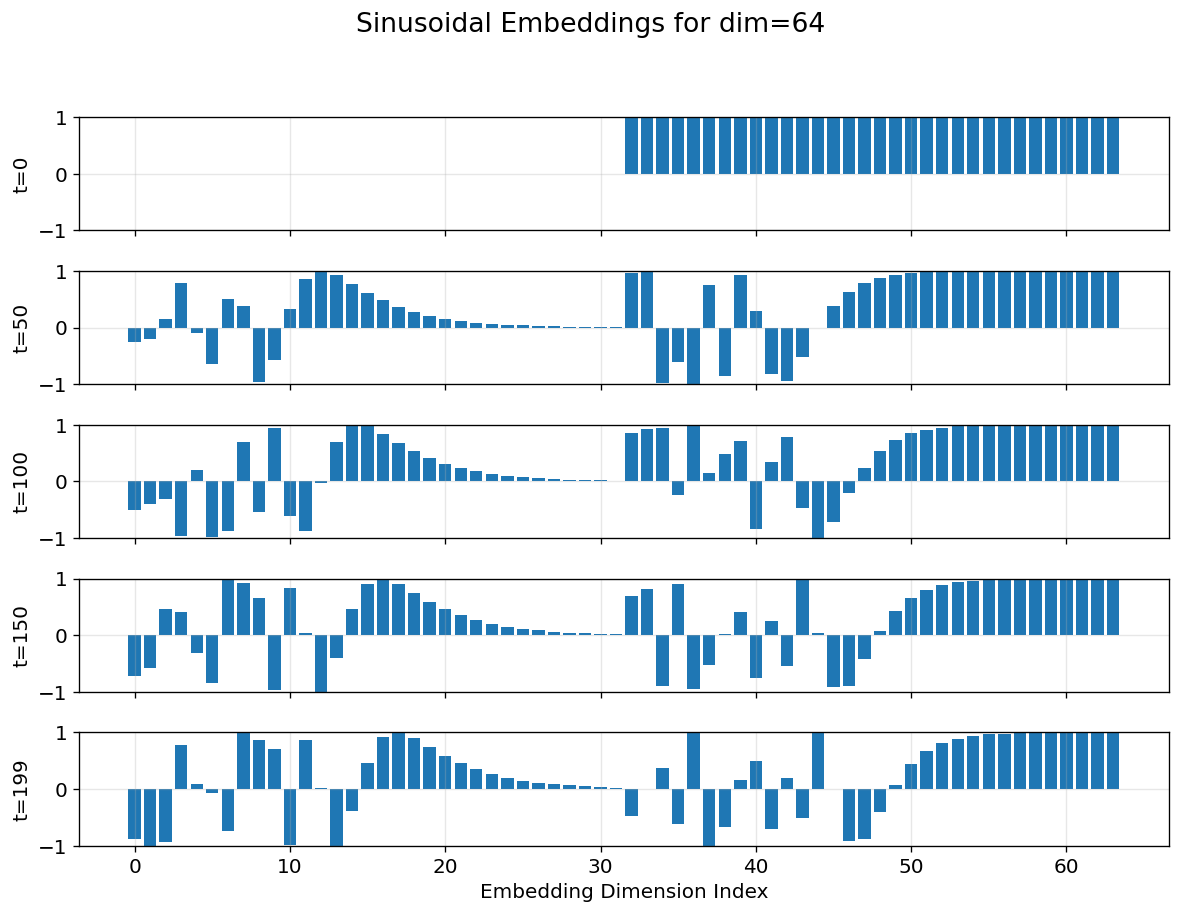


--- Visualization 2: Embedding Value vs. Timestep for Selected Dimensions ---


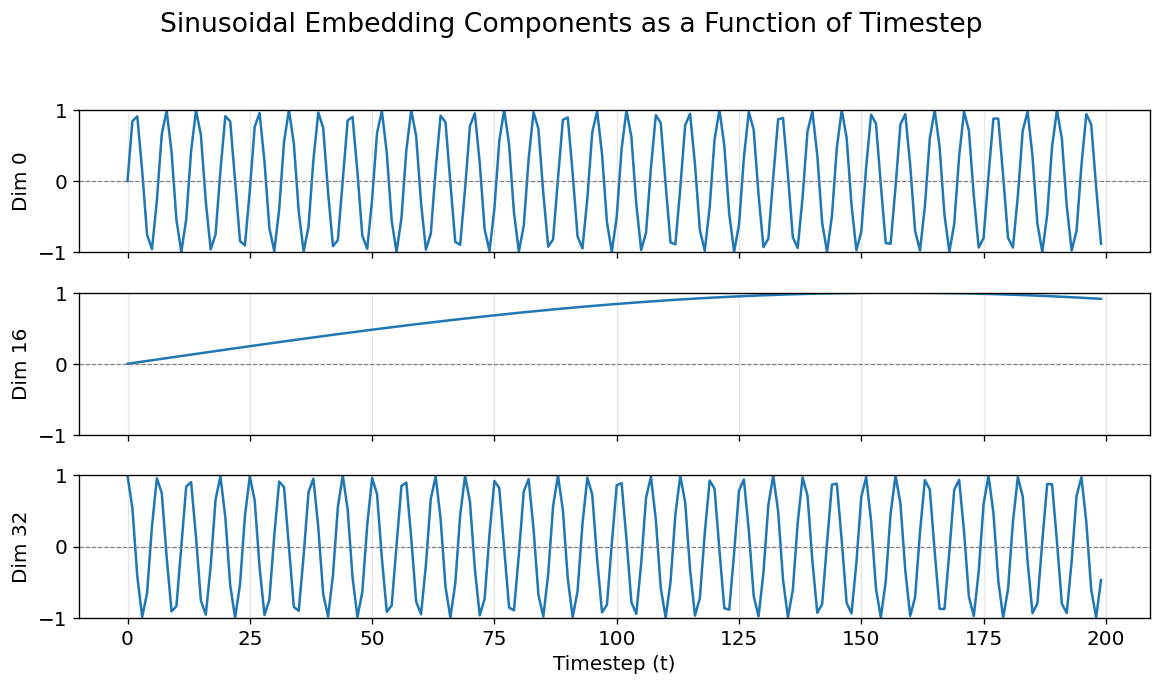

In [17]:
def sinusoidal_embedding(t, dim):
    # Ensure dim is even
    assert dim % 2 == 0, "Embedding dimension must be an even integer"

    # Compute frequencies
    # freqs[i] = exp(-log(10000) * i / (dim/2))
    # log_term = -math.log(10000) / (dim / 2)
    # freqs = torch.exp(torch.arange(0, dim // 2) * log_term)
    frequencies = torch.exp(
        torch.arange(0, dim // 2, device=t.device).float() * (-math.log(10000.0) / (dim // 2))
    )

    # Rearrange t and frequencies for broadcasting
    # args[b, i] = t[b] * freqs[i]
    args = rearrange(t, 'b -> b 1') * rearrange(frequencies, 'f -> 1 f')

    # Stack sin and cos along the feature dimension
    embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return embedding


# --- Visualization tasks for Task 36 ---

# Visualization 1: Five 64-dimensional vectors for specific t values
print("\n--- Visualization 1: Specific Timestep Embeddings ---")
d_embed = 64
t_values_viz1 = torch.tensor([0, T // 4, T // 2, 3 * T // 4, T - 1], dtype=torch.long)
embeddings_viz1 = sinusoidal_embedding(t_values_viz1, d_embed)

fig_viz1, axes_viz1 = plt.subplots(len(t_values_viz1), 1, figsize=(10, 8), sharex=True)
fig_viz1.suptitle(f'Sinusoidal Embeddings for dim={d_embed}', fontsize=16)

for i, t_val in enumerate(t_values_viz1):
    axes_viz1[i].bar(range(d_embed), embeddings_viz1[i].numpy())
    axes_viz1[i].set_ylabel(f't={t_val}')
    axes_viz1[i].set_ylim(-1, 1)

plt.xlabel('Embedding Dimension Index')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Visualization 2: Embedding value as a function of t for three dimensions
print("\n--- Visualization 2: Embedding Value vs. Timestep for Selected Dimensions ---")
t_range_viz2 = torch.arange(0, T, dtype=torch.long)
embeddings_viz2 = sinusoidal_embedding(t_range_viz2, d_embed)

selected_dims = [0, 16, 32]

fig_viz2, axes_viz2 = plt.subplots(len(selected_dims), 1, figsize=(10, 6), sharex=True)
fig_viz2.suptitle('Sinusoidal Embedding Components as a Function of Timestep', fontsize=16)

for i, dim_idx in enumerate(selected_dims):
    axes_viz2[i].plot(t_range_viz2.numpy(), embeddings_viz2[:, dim_idx].numpy())
    axes_viz2[i].set_ylabel(f'Dim {dim_idx}')
    axes_viz2[i].axhline(0, color='gray', linestyle='--', linewidth=0.7)
    axes_viz2[i].set_ylim(-1, 1)

plt.xlabel('Timestep (t)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
## Task 37 — Wrap the sinusoidal embedding in a learnable module

The raw sinusoidal embedding is fixed: it has no learnable parameters and
its representation of t is determined entirely by the formula. To let the
main network shape the t-representation it actually wants, we wrap the
sinusoidal embedding in a small MLP that *learns* to project the fixed
sinusoidal representation into a useful form. This wrapper is the
`TimestepEmbedding` module.

The wrapping pattern (fixed positional encoding → learnable projection)
is standard across Transformer-style architectures. It separates the
"how do I represent integer position as a vector" question (solved
analytically by the sinusoidal formula) from the "what t-information does
my downstream network find useful" question (solved by gradient descent
through the MLP).

**Tasks:**
- Implement `TimestepEmbedding(nn.Module)` with constructor arguments
  `embed_dim` (the dimension of the raw sinusoidal embedding, 64 by
  default) and `hidden_dim` (the dimension of the learned projection,
  128 by default).
- The constructor should build a small MLP:
  `Linear(embed_dim, hidden_dim) → SiLU → Linear(hidden_dim, hidden_dim)`.
  We use SiLU (also called Swish: x · sigmoid(x)) because it is the
  conventional activation in diffusion models and gives smoother gradients
  than ReLU at deep noise levels. ReLU also works; SiLU is just the
  standard pick.
- The `forward(self, t)` method takes `t` of shape `(B,)`, calls
  `sinusoidal_embedding(t, self.embed_dim)`, and returns the result of the
  MLP, of shape `(B, hidden_dim)`.

**Sanity check:** instantiate `TimestepEmbedding(embed_dim=64, hidden_dim=128)`,
construct a tensor `t = torch.arange(0, T, T // 8)` (shape `(8,)`), and
verify that `module(t)` returns a tensor of shape `(8, 128)` with no NaNs.


In [ ]:
# Put your code here for Task 37.


---
## Task 38 — Build the DiffusionMLP with an ablation flag

The main network: an MLP that takes (r_t, t), concatenates the timestep
embedding with r_t at the input, pushes through a stack of fully connected
layers, and returns ε̂ — the network's prediction of the noise that was
added. The output has the same shape as r_t.

The diffusion-specific architectural concern here is *how* t enters the
network. We use **input concatenation**: the timestep embedding is
appended to r_t at the input layer, and the MLP learns to read both pieces
from the concatenated vector. Two alternatives exist that are common in
image diffusion models — FiLM (feature-wise modulation, where t scales and
shifts feature maps at every layer) and cross-attention (where t serves as
a key/value pair attended to from r_t) — but for 15-dimensional data and
a 3-layer MLP, both are overkill. Input concatenation is the right level
of complexity for the residual problem.

The constructor takes a `use_timestep_embedding=True/False` flag. When
True, the network builds a TimestepEmbedding and concatenates its output
with r_t. When False, the network has no TimestepEmbedding, the input
dimension is just `data_dim=15`, and the network is t-blind — it produces
the same output regardless of t. The False setting is the **architectural
ablation** we will use in Task 44 to measure whether the timestep
embedding actually earns its keep on this dataset.

**Tasks:**
- Implement `DiffusionMLP(nn.Module)` with constructor arguments:
  - `data_dim=15` — the residual dimension.
  - `hidden_dim=128` — the MLP hidden width.
  - `t_embed_dim=64` — the sinusoidal embedding dimension.
  - `t_hidden_dim=128` — the TimestepEmbedding output dimension.
  - `n_layers=3` — the number of hidden layers in the main MLP.
  - `use_timestep_embedding=True` — the ablation flag.
- When `use_timestep_embedding=True`:
  - Build a `TimestepEmbedding(t_embed_dim, t_hidden_dim)` and store it.
  - Set the main MLP's input dimension to `data_dim + t_hidden_dim`.
- When `use_timestep_embedding=False`:
  - Do not build a TimestepEmbedding.
  - Set the main MLP's input dimension to just `data_dim`.
- Build the main MLP as `n_layers` hidden layers of `hidden_dim` units
  each, with SiLU activations between them, and a final
  `Linear(hidden_dim, data_dim)` output layer (no activation on the
  output — ε can take any real value).
- The `forward(self, r_t, t)` method:
  - Takes `r_t` of shape `(B, data_dim)` and `t` of shape `(B,)`.
  - When the flag is True, computes `t_emb = self.t_embedding(t)` and
    concatenates with `r_t` along the feature dimension to form the input.
  - When the flag is False, the input is just `r_t`.
  - Returns the MLP output, of shape `(B, data_dim)`.

The forward signature `(r_t, t) → eps_hat` is the contract the
LightningModule in Task 40 will rely on. Both the True and False
configurations satisfy this contract; in the False case, the network
simply ignores `t` entirely.


In [ ]:
# Put your code here for Task 38.


---
## Task 39 — Sanity-test the model, including the t-sensitivity check

Before training anything, two model bugs to rule out. The first is
mundane: shape mismatches at the input or output of the MLP, which will
raise a clear PyTorch error. The second is much more dangerous: a model
that *looks* fine — accepts (r_t, t), produces an output of the right
shape, trains without error — but silently ignores t even when
`use_timestep_embedding=True`. This can happen if the timestep embedding
is implemented but its output is dropped before the concatenation, if the
concatenation axis is wrong, or if the embedding produces all-zero or
all-NaN outputs. None of these failures raise. They only become visible
when the ablation comparison in Task 44 produces "the timestep embedding
doesn't help" — and at that point you cannot tell whether the embedding
is genuinely unhelpful or simply broken.

The defense is the **t-sensitivity check**: hold `r_t` fixed, vary `t`,
and verify that the model's output measurably changes. For
`use_timestep_embedding=True` the change should be non-trivial; for
`use_timestep_embedding=False` the change should be exactly zero (the
network has no path through which t can affect its output).

**Tasks:**
- Instantiate two models:
  - `model_full = DiffusionMLP(use_timestep_embedding=True)`.
  - `model_blind = DiffusionMLP(use_timestep_embedding=False)`.
- For each model:
  - Construct a random batch `r_t = torch.randn(8, 15)` and a random
    `t = torch.randint(0, T, (8,))`.
  - Run `model(r_t, t)` and confirm the output has shape `(8, 15)` with
    no NaNs.
  - Print the total parameter count
    (`sum(p.numel() for p in model.parameters())`). The full model should
    have *more* parameters than the blind model — the difference is exactly
    the parameter count of the TimestepEmbedding module, which the blind
    model does not build.
- **t-sensitivity check (the critical one):**
  - Construct a single fixed input `r_t_fixed = torch.randn(15)` (shape `(15,)`).
  - Construct five timesteps `t_values = torch.tensor([0, T//4, T//2, 3*T//4, T-1])`.
  - Use `einops.repeat(r_t_fixed, 'd -> n d', n=5)` to build a `(5, 15)`
    batch with identical r_t but different t. Do not use `expand` or `tile`.
  - For each model, compute the model output and then the pairwise L2
    distance between rows (a 5 × 5 matrix). For `model_full`, the
    off-diagonal entries should be visibly non-zero. For `model_blind`,
    they should be exactly zero
    (`torch.allclose(output_blind[i], output_blind[j])` should hold for
    any i, j).
  - Display the two 5 × 5 distance matrices as heatmaps side by side. The
    full-model heatmap should show off-diagonal structure; the
    blind-model heatmap should be uniformly zero off-diagonal (a flat
    color map).

If the full-model heatmap is also uniformly zero off-diagonal, your
TimestepEmbedding is broken. Fix it before proceeding to Task 40 — every
downstream task will silently misbehave otherwise.


In [ ]:
# Put your code here for Task 39.


---
## Task 40 — Wrap the model in a LightningModule

The `DiffusionMLP` from Task 38 is a `nn.Module`: it knows how to compute
ε̂ from (r_t, t), but it does not know what to train on, what loss to
minimize, what optimizer to use, or how to use the noise schedule.
PyTorch Lightning's `LightningModule` is the wrapper that adds these
training-specific responsibilities. When you write a Lightning module,
you are answering five questions:

1. *What submodules does the model contain?* (`__init__`)
2. *What constants does it need that are not learnable?* (`register_buffer`)
3. *What does one training step look like?* (`training_step`)
4. *What does one validation step look like?* (`validation_step`)
5. *What optimizer trains it?* (`configure_optimizers`)

For diffusion, the diffusion-specific content sits almost entirely in
question 3 — the training step is where the schedule, the forward
corruption, and the MSE-on-ε loss all converge. The other four questions
have boilerplate-ish answers.

A specific design point: the schedule arrays α and σ from Task 28 of
Week 07 are *constants* (no learnable parameters) but they need to live
on the same device as the model and be saved with the checkpoint. The
PyTorch idiom for that is `register_buffer` — call it in `__init__` with
the precomputed schedule tensors. They will then sit alongside the
model's parameters in the state dict, follow the model to GPU
automatically, and not get updated by the optimizer.

The arrays `alpha_np` and `sigma_np` are already in scope from the setup
cell — same cosine schedule formula as Week 07, recomputed here so this
notebook is self-contained. We pass them as constructor arguments and
register them as buffers, rather than recomputing the cosine formula
inside `__init__`. This keeps the schedule choice visible at the call
site and makes the LightningModule's `training_step` schedule-agnostic:
swap `alpha_np`, `sigma_np` for arrays from a linear schedule and nothing
in the training step changes.

**Tasks:**
- Define a class `DiffusionLightning(pl.LightningModule)`.
- Constructor takes:
  - `model` — an instantiated `DiffusionMLP`.
  - `alpha`, `sigma` — the 1D arrays from the setup cell (each of length T+1).
  - `T` — the number of timesteps (200).
  - `lr=1e-3` — the Adam learning rate.
- In the constructor:
  - Store the model as `self.model`.
  - Convert `alpha` and `sigma` to `torch.float32` tensors and register
    them as buffers (named `'alpha'` and `'sigma'`).
  - Store `T` and `lr` as attributes.
- Implement `training_step(self, batch, batch_idx)`:
  - `batch` is a tensor of clean residuals, shape `(B, 15)`. Call it
    `r_clean`.
  - Sample `t = torch.randint(0, self.T, (B,), device=r_clean.device)`.
  - Draw `eps = torch.randn_like(r_clean)`.
  - Look up `alpha_t = self.alpha[t]` and `sigma_t = self.sigma[t]`,
    each of shape `(B,)`.
  - Use `einops.rearrange(alpha_t, 'b -> b 1')` (and similarly for sigma_t)
    so they broadcast cleanly against `r_clean` of shape `(B, 15)`.
  - Compute `r_t = alpha_t * r_clean + sigma_t * eps`.
  - Compute `eps_hat = self.model(r_t, t)`.
  - Compute `loss = F.mse_loss(eps_hat, eps)`.
  - Log via `self.log('train_loss', loss, prog_bar=True)`.
  - Return `loss`.
- Implement `validation_step(self, batch, batch_idx)`:
  - Same structure as `training_step`, but log as `'val_loss'` and do not
    set `prog_bar=True`.
- Implement `configure_optimizers(self)`:
  - Return `torch.optim.Adam(self.parameters(), lr=self.lr)`.

**Conceptual note worth pausing on:** the `training_step` is fully
*schedule-agnostic*. It looks up `self.alpha[t]` and `self.sigma[t]`
from the buffers and uses them; it does not know whether those values
came from a cosine, linear, or any other schedule formula. Swapping
schedules later (Week 09 onward, if you want to compare schedule
families) will only require changing what you pass to the constructor
— not a single line of `training_step` will change. This is the
separation of concerns we want to preserve as the pipeline grows.


In [ ]:
# Put your code here for Task 40.


---
## Task 41 — Train the unconditional diffusion model

With the dataset, dataloaders, model, and Lightning module in place, the
training loop becomes a few lines of glue: instantiate everything, hand
to a `Trainer`, and call `fit`. This is the payoff of the AI/ML pipeline
abstraction — the wiring you spent Tasks 33–40 building lets the actual
training command be tiny.

We will use **Weights & Biases (WandB)** for experiment logging. WandB
gives you live loss curves, hyperparameter tracking, and a comparison
view across runs that will be especially useful when the ablation in
Task 44 produces a second run to compare against the first. If you have
not used WandB before, the first run will prompt you to log in (free
account, follow the URL it gives you).

**Tasks:**
- Instantiate `model_full = DiffusionMLP(use_timestep_embedding=True)`.
- Instantiate
  `lightning_full = DiffusionLightning(model_full, alpha=alpha_np, sigma=sigma_np, T=T)`.
- Create a `WandbLogger` with `project='butterflai-wk08'` and a clear run
  name like `'unconditional_full'`.
- Create a `pl.Trainer`:
  - `max_epochs=200` (15-dim data is small; epochs are fast).
  - `logger=wandb_logger`.
  - `accelerator='auto'`, `devices='auto'`.
  - `log_every_n_steps=10`.
- Call `trainer.fit(lightning_full, train_loader, val_loader)`.
- After training completes, save the model checkpoint to a known path
  (e.g. `'./ckpt_full.ckpt'`) using `trainer.save_checkpoint(...)`.
- Plot the training and validation loss curves from the logged history.
  Both should decrease, with the val loss eventually plateauing or
  rising slowly if the model overfits.

**Important callout — what loss does and does not tell you:** a decreasing
training loss is necessary but **not sufficient** for a good diffusion
model. The training loss is the MSE between the network's predicted ε
and the true ε; it measures how well the network estimates the noise
that was added during corruption. It does *not* directly measure whether
the samples drawn from the trained model look like the training data. A
model can have a low MSE-on-ε and still produce samples that are
visually wrong — for example, if the network has memorized the marginal
mean of ε but not the per-r_t structure. We will evaluate sample quality
directly in Task 43, after we have built a sampler in Task 42.


In [ ]:
# Put your code here for Task 41.


---
## Task 42 — Implement a DDIM-style sampler

Sampling is the *inference* counterpart of training. Training corrupts
clean residuals to noise: we take a clean r, pick a random t, and produce
r_t. Sampling reverses that path: we start from pure noise r_T ~ N(0, I)
and step backward through the schedule until we arrive at a clean r_0 —
a generated residual.

There is an asymmetry between training and sampling worth pausing on.
Training is *parallel* over t: every sample in a batch gets an independent
random t, all denoised in a single forward pass through the network.
Sampling is *sequential*: you must walk the schedule from t = T-1 down to
t = 0, calling the network at every step. With T = 200 timesteps, sampling
one batch of residuals takes 200 sequential forward passes; training one
batch takes one. This is why training scales pleasantly with batch size
but sampling does not.

The reverse step we implement is **deterministic DDIM** (Song, Meng,
Ermon 2020). DDIM is mathematically related to the more famous DDPM
(Ho, Jain, Abbeel 2020), but DDIM removes the per-step random noise and
makes the sampling process deterministic given the starting r_T. The
advantages: simpler code, easier debugging, identical sample quality with
many fewer steps if you want to skip timesteps. The DDIM step using the
α_t / σ_t parameterization from Week 07 is:

```
ε̂        = model(r_t, t)
r̂_0      = (r_t - σ_t · ε̂) / α_t              # estimate the clean residual
r_{t-1}  = α_{t-1} · r̂_0 + σ_{t-1} · ε̂        # step to t-1 along the same direction
```

Read the second line carefully: we use the *same* ε̂ from the model both
to estimate r̂_0 and to step to t-1. That is the essence of the
deterministic DDIM step.

**Tasks:**
- Implement a function
  `sample(lightning_module, batch_size, data_dim, device)` that returns
  a batch of generated residuals of shape `(batch_size, data_dim)`. The
  function should pull `alpha`, `sigma`, and `T` from the
  `lightning_module`'s buffers and attributes.
- The function should:
  - Set `lightning_module.eval()` and wrap the body in `torch.no_grad()`.
  - Initialize `r_t = torch.randn(batch_size, data_dim, device=device)`.
  - Loop `t` from `T - 1` down to `0`:
    - Construct
      `t_batch = torch.full((batch_size,), t, dtype=torch.long, device=device)`.
    - Compute `eps_hat = lightning_module.model(r_t, t_batch)`.
    - Look up `alpha_t = lightning_module.alpha[t]`,
      `sigma_t = lightning_module.sigma[t]` (scalars).
    - Compute `r_0_hat = (r_t - sigma_t * eps_hat) / alpha_t`.
    - If `t > 0`:
      `r_t = lightning_module.alpha[t-1] * r_0_hat + lightning_module.sigma[t-1] * eps_hat`.
    - If `t == 0`: `r_t = r_0_hat` (the final estimate is the clean sample).
  - Return `r_t`.

**Sanity check:** call `sample(lightning_full, batch_size=8, data_dim=15, device=device)`
and verify the output has shape `(8, 15)` with no NaNs. Plot the eight
samples as bar charts on a 2 × 4 grid using `BIN_CENTERS`. They should
look like residuals (zero-mean-ish, structure in middle bins, small at
edges) — but at this point all you can confirm is "they don't look
obviously broken." The quantitative comparison against the training
distribution is Task 43.

**Note on alternatives:** The stochastic DDPM step adds a fresh ε draw at
each timestep, producing different samples from the same starting r_T.
DDPM is the more conventional choice in the literature; DDIM is what we
use here for pedagogical simplicity. If you finish early and are curious,
add a `stochastic=True` flag and implement the DDPM step
`r_{t-1} = α_{t-1} · r̂_0 + sqrt(σ_{t-1}^2 - eta^2) · ε̂ + eta · z` where
`z ~ N(0, I)` and `eta` is the step's noise level (commonly η = σ_{t-1}
for full DDPM, η = 0 for DDIM).


In [ ]:
# Put your code here for Task 42.


---
## Task 43 — Verify the sampled distribution matches the training distribution

The training loss tells you the network is learning *something*; it does
not tell you the network has learned the *right* thing. The direct
empirical question is: do samples from the trained model look like real
training residuals? At the level of distributional statistics, if the
model has learned the marginal residual distribution well, its samples
should match the training residuals on bin-wise mean, bin-wise standard
deviation, and bin-bin covariance structure.

This task asks you to compute and visualize that comparison. The
diagnostics are the same three you used in Task 31 of Week 07 to verify
the forward process — bin-wise mean, bin-wise standard deviation, and
covariance matrix — applied here to two distributions: the empirical
training residuals and the model-generated residuals.

**Tasks:**
- Sample 1000 residuals from the trained full model:
  `samples_full = sample(lightning_full, batch_size=1000, data_dim=15, device=device).cpu().numpy()`.
- Collect 1000 random training residuals into a numpy array of shape
  `(1000, 15)` (sample with replacement from `train_dataset` if needed).
- Compute the **bin-wise mean** for both, plot side-by-side as bar charts
  using `BIN_CENTERS`. They should agree within ~`1/sqrt(1000) ≈ 3%` of
  typical residual scale.
- Compute the **bin-wise standard deviation** for both, plot side-by-side.
  They should agree similarly.
- Compute the **bin-bin covariance matrix** (15 × 15) for both, plot
  side-by-side as heatmaps with the same color scale. The model's
  covariance should reproduce the diagonal (per-bin variance) and the
  dominant off-diagonal structure (correlations between neighboring bins,
  anti-correlations between distant bins) of the training data.
- **Visual overlay:** plot 20 random training residuals and 20 random
  model samples on the same axes (different colors). They should be
  visually indistinguishable — same overall envelope, same kind of
  structure in the middle bins, same near-zero behavior at edges. If the
  model samples are visibly smoother or more uniform than the training
  residuals, the model has under-learned. If they are visibly noisier or
  spikier, the model has under-trained or has a bug.
- Compute and report a single scalar summary: the **bin-wise MSE** between
  the sampled bin-wise mean and the training bin-wise mean. We will reuse
  this number in Task 44 to compare against the ablation.

**Caveat to flag:** because this week's model is *unconditional*, it is
matching the *marginal* training distribution — averaged across all cycles,
phases, and amplitudes. It is not learning to generate residuals
appropriate for any specific window. That is fine for this week; it is
exactly what the unconditional model is supposed to do. The check
"do generated residuals match the training-set marginals" is the right
test for the unconditional model.

**Optional ad-hoc inspection:** if you want to see what a sampled residual
"adds" to a classical prediction, pick any window from `windows_df`, look
up its `(amplitude, tau_center)`, evaluate `classical.density(A, tau, BIN_CENTERS)`
to get the classical density on the bin grid, integrate it to get the
binned classical histogram, and overlay it with `binned_classical + r_sample`
for a few sampled residuals. The combined predictions will *not*
systematically improve over the classical alone for this specific window —
the residual is a draw from the marginal, not targeted at this window's
amplitude or phase. Conditioning on (amplitude, mu_universal) in Week 09
is what makes the residual targeted; the corresponding `compute_global_nll`
value-add metric arrives there.


In [ ]:
# Put your code here for Task 43.


---
## Task 44 — Run the no-timestep-embedding ablation

The whole reason for the ablation flag in Task 38 is the question this
task answers: does the timestep embedding earn its keep? We trained one
model with `use_timestep_embedding=True`. Now we train a second, identical
in every other respect, with `use_timestep_embedding=False`. The
**ablation comparison** is the two models' performance on the same metrics
from Task 43. If the t-blind model does almost as well, the timestep
embedding is not contributing much (or is broken — Task 39 should have
ruled the latter out). If the t-blind model does substantially worse,
the timestep embedding earns its keep.

There is a useful prediction to commit to before running this task. The
t-blind model has only one possible strategy: it must produce a single
ε estimate that is averaged over all noise levels — a kind of "average
denoiser" that does not adapt to the noise level it is currently looking
at. At low t, where the input is mostly clean, this average denoiser will
add too much noise to the estimate; at high t, where the input is mostly
noise, it will subtract too little. The net effect on samples is
typically that the marginal mean and variance roughly match (because the
overall scale is correct on average) but the covariance structure
collapses — the model loses the per-bin correlations that distinguish
training residuals from white noise.

Predict before you run. Then run.

**Tasks:**
- Instantiate `model_blind = DiffusionMLP(use_timestep_embedding=False)`.
- Instantiate
  `lightning_blind = DiffusionLightning(model_blind, alpha=alpha_np, sigma=sigma_np, T=T)`.
- Train it with the same Trainer configuration as Task 41, but with a
  distinct WandB run name like `'unconditional_blind'`. Use the same
  `max_epochs`, the same DataLoaders, the same learning rate. Save the
  checkpoint to `'./ckpt_blind.ckpt'`.
- Sample 1000 residuals from the trained blind model.
- Re-run all three diagnostics from Task 43 (bin-wise mean, std,
  covariance heatmap) for the blind model.
- Build a comparison table with three rows (training data, full model,
  blind model) and four columns (final train_loss, final val_loss,
  bin-wise mean MSE vs. training, qualitative covariance match yes/no).
- Plot the two covariance heatmaps (full and blind) side by side. The
  qualitative comparison is the headline result: does the blind model's
  covariance match the training data's, or has it collapsed to something
  more diagonal?

**How to read the result:**

- *If the full model clearly beats the blind model* on covariance match:
  the timestep embedding earns its keep. The architectural complexity is
  doing real work, and Week 09's conditioning machinery should be built
  on top of the t-aware base.
- *If the two models are nearly tied:* the timestep embedding is not
  contributing much on this dataset. Possible reasons: 200 timesteps is
  more than this 15-dimensional residual problem needs (a network can
  approximately memorize an "average denoiser" when the noise levels are
  not too varied); the cosine schedule keeps the signal alive across a
  large fraction of t (so the average denoiser is not far from any
  specific denoiser); or the data does not have enough structure across
  noise levels for t-awareness to matter. None of these is a bug — they
  are real findings about this problem at this scale.
- *If the blind model outperforms the full model:* a real bug somewhere,
  most likely in the TimestepEmbedding or in the concatenation. Re-run
  Task 39's t-sensitivity check to localize.

Either of the first two outcomes is publishable insight about your
specific problem. The result is not predetermined — that is what makes
this an ablation rather than a demonstration.


In [ ]:
# Put your code here for Task 44.


---
## Where Week 08 leaves us, and what Week 09 will need

By the end of Task 44 you have built every piece of the AI/ML pipeline a
PyTorch + Lightning project needs, instantiated for the unconditional
diffusion model:

- A **PyTorch Dataset** that wraps the Week 07 residual table loaded
  from `diffusion_windows.parquet` (Task 33).
- A set of **DataLoaders** for train / val / test using the parquet's
  `split` column with appropriate shuffling (Task 35).
- A **sinusoidal timestep embedding** that turns integer t into a dense
  vector (Task 36) and a **TimestepEmbedding module** that learns to
  project that vector into a useful representation (Task 37).
- A **DiffusionMLP** that takes (r_t, t) and predicts ε̂, with a flag for
  the architectural ablation (Task 38), sanity-tested for shape and
  t-sensitivity (Task 39).
- A **LightningModule** that stitches the model and the Week 07 schedule
  into a training loop (Task 40), trained end-to-end with WandB logging
  (Task 41).
- A **DDIM sampler** that runs the trained model in reverse to generate
  new residuals (Task 42).
- Two empirical results: the **distributional verification** that the
  trained model's samples match the training distribution (Task 43) and
  the **timestep-embedding ablation** that measures whether the
  diffusion-specific architecture earns its keep (Task 44).

What you have **not** yet built is conditioning: every sample drawn from
the trained model is from the *marginal* residual distribution, not from
a distribution targeted at a specific window. That is the Week 09 lift.

**What changes in Week 09.** The Dataset returns
`(r, amplitude, mu_universal)` tuples instead of just `r` (the parquet
already has those columns). The DiffusionMLP gains a second concatenation
input — the conditioning vector — alongside the timestep embedding. The
LightningModule's `training_step` passes the conditioning through. The
sampler accepts a per-sample conditioning vector and threads it through
each reverse step. None of the diffusion-specific machinery (the schedule,
the forward equation, the ε-prediction objective, the timestep embedding
itself) changes. The conditioning is an *extension* of the architecture
you have already built, not a replacement for it.

**What stays.** Every line of `training_step`. Every line of the sampler
loop. The LightningModule structure. The schedule buffers. The full
ablation infrastructure. Week 09 is a small refactor on a working
pipeline, not a rebuild.

**What we expect to see in Week 09.** With conditioning, the combined
classical + diffusion model (the official `ButterflAIModel.density(A, tau, ·)`
loaded as `classical` in this notebook's setup, plus a sampled residual
targeted at that window's amplitude and mu_universal) should outperform
the classical model alone on `compute_global_nll` for held-out test
cycles. That is the value-add metric the program has been pointing at
since Week 03. Whether the margin is large or small is itself a real
empirical question, and it is the question Week 09 finally lets you
answer.
